# ThreatLLM — Pipeline de Triage de Amenazas con NLP + LLM
### Presentación para cliente — Proyecto Integrador, Equipo 11

**Integrantes:** Alicia Canta Pandal · Miguel Silva Ramos · Marco Antonio Corona Ruiz

---

## ¿Qué hace ThreatLLM?

ThreatLLM automatiza la **primera fase del triage de ciberseguridad**: toma un reporte de
inteligencia de amenazas (CTI) en texto libre —largo, no estructurado, escrito por analistas—
y produce evidencia estructurada y accionable en tres pasos:

1. **Detecta** qué oraciones del reporte describen una acción de ataque real (vs. contexto/ruido).
2. **Vincula** esas oraciones con técnicas conocidas del framework **MITRE ATT&CK**, usando similitud semántica.
3. **Empaqueta** todo en un JSON + prompt para que un LLM emita el **veredicto final de severidad**.

```
Reporte CTI crudo (texto libre)
        │
        ▼
[1] Clasificador de oraciones  →  ¿es una descripción de ataque?
        │
        ▼
[2] Matching semántico con MITRE ATT&CK  →  ¿qué técnica es?
        │
        ▼
[3] JSON estructurado + prompt  →  LLM asigna severidad final
```

**Por qué importa para el negocio:** un SOC (Security Operations Center) recibe miles de alertas;
el 62% de los analistas reporta fatiga por exceso de alertas y detectar una brecha toma en
promedio 204 días (IBM, *Cost of a Data Breach Report*, 2024). ThreatLLM reduce ese cuello de
botella filtrando y estructurando automáticamente la evidencia antes de que un humano —o un LLM—
tenga que decidir.

**Dataset base:** LADDER — *Looking Beyond IoCs* (Orbinato et al., RAID 2023): 3,444 oraciones
etiquetadas (ataque / contexto) y un ground-truth de 81 técnicas MITRE ATT&CK sobre malware
bancario móvil.

> **Nota sobre este notebook:** para que la demo se ejecute de punta a punta sin depender de
> archivos externos ni de descargar modelos pesados, se usa un **subconjunto ilustrativo** de
> datos con la misma estructura que el dataset real LADDER. El pipeline, la lógica y las
> métricas son exactamente las del proyecto completo.


## 0. Configuración del entorno

Se importan las librerías necesarias. En producción, la codificación semántica de oraciones se
hace con el transformer **`sentence-transformers/all-MiniLM-L6-v2`**; en este entorno de
demostración (sin acceso a red) se usa automáticamente un *fallback* con TF-IDF, que cumple el
mismo rol — convertir texto en un vector numérico — de forma más ligera.

In [1]:

import re, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
np.random.seed(42)

# --- Intento de usar el encoder real; fallback automático a TF-IDF ---
USE_TRANSFORMER = False
try:
    from sentence_transformers import SentenceTransformer
    _st_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
    USE_TRANSFORMER = True
except Exception:
    _st_model = None

print(f"Encoder semantico en uso: {'MiniLM (transformer)' if USE_TRANSFORMER else 'TF-IDF (fallback offline)'}")


Encoder semantico en uso: TF-IDF (fallback offline)


## 1. La métrica de severidad — `threat_composite_score` (CTS)

Este es el corazón analítico del proyecto: **¿cómo se traduce una técnica de ataque en un número
de severidad?** MITRE ATT&CK describe *qué* hace un atacante (tácticas y técnicas) pero
**deliberadamente no asigna una puntuación de severidad** (Strom et al., 2018), porque el riesgo
real depende del contexto de cada organización. Para poder priorizar alertas, ThreatLLM construye
su propia métrica compuesta: el **Composite Threat Score (CTS)**.

### La fórmula

$$
\text{CTS}(t) \;=\; \underbrace{0.50 \cdot \max(W_t)}_{\text{peor escenario}} \;+\; \underbrace{0.30 \cdot \text{mean}(W_t)}_{\text{severidad promedio}} \;+\; \underbrace{0.20 \cdot V(t)}_{\text{versatilidad}}
$$

Donde, para una técnica $t$:

| Término | Qué mide | Por qué importa |
|---|---|---|
| $\max(W_t)$ | El peso de la **táctica más peligrosa** entre todas las que toca la técnica | Una técnica que *también* puede usarse para Exfiltración (0.85) es peligrosa aunque su uso típico sea más leve — el peor caso no debe diluirse |
| $\text{mean}(W_t)$ | El **promedio** de los pesos de todas sus tácticas | Evita que una sola táctica extrema domine por completo la puntuación |
| $V(t) = \dfrac{\text{núm. tácticas de } t}{\text{máx. tácticas observado}}$ | Qué tan **versátil** es la técnica (cuántas fases cubre) | Una técnica multi-táctica (ej. cruza *Collection* + *Credential Access*) le da al atacante más opciones de pivote → mayor riesgo estructural |

Los pesos $W$ por táctica siguen la lógica del **kill chain** (Lockheed Martin): las fases
tempranas (Reconnaissance = 0.10) son de bajo daño inmediato; las fases finales
(Exfiltration = 0.85, Impact = 0.95) representan el daño consumado.

### ¿Por qué esta combinación y no solo un promedio?

- **Solo el promedio** subestimaría técnicas que —aunque en promedio parezcan moderadas—
  tienen la *capacidad* de escalar a una táctica crítica (por eso el 50% de peso va al peor caso).
- **Solo el máximo** ignoraría que algunas técnicas solo tocan tácticas leves de forma consistente.
- **La versatilidad** es un factor estructural: en incidentes reales (ej. SolarWinds, 2020) las
  técnicas que encadenan múltiples fases del ataque son las que requieren escalamiento
  automático de prioridad.

### Categorías de severidad

El CTS (continuo, 0–1) se discretiza en 4 bandas — **coherentes con el estándar CVSS v4.0**
(Low/Medium/High/Critical) adaptado a este rango:

| Categoría | Rango CTS | Equivalente CVSS |
|---|---|---|
| Bajo | 0.00 – 0.35 | Low |
| Medio | 0.35 – 0.55 | Medium |
| Alto | 0.55 – 0.70 | High |
| Crítico | 0.70 – 1.00 | Critical |

Y una bandera binaria `is_high_impact = 1` cuando `CTS ≥ 0.70`, útil como filtro rápido de
escalamiento para el SOC.

In [2]:

# Pesos tacticos normalizados segun la posicion en el kill chain (MITRE ATT&CK Mobile)
TACTIC_WEIGHTS = {
    "Reconnaissance": 0.10, "Resource Development": 0.15, "Initial Access": 0.25,
    "Execution": 0.40, "Persistence": 0.45, "Privilege Escalation": 0.60,
    "Defense Evasion": 0.55, "Credential Access": 0.65, "Discovery": 0.35,
    "Lateral Movement": 0.50, "Collection": 0.70, "Command and Control": 0.55,
    "Exfiltration": 0.85, "Impact": 0.95,
}

# Subconjunto ilustrativo del mapeo tecnica -> tacticas (MITRE ATT&CK Mobile Matrix)
TECHNIQUE_MAP = {
    "T1418": {"name": "Software Discovery",               "tactics": ["Discovery"]},
    "T1409": {"name": "Stored Application Data",           "tactics": ["Collection"]},
    "T1481": {"name": "Web Service",                       "tactics": ["Command and Control"]},
    "T1417": {"name": "Input Capture",                     "tactics": ["Collection", "Credential Access"]},
    "T1513": {"name": "Screen Capture",                    "tactics": ["Collection"]},
    "T1634": {"name": "Credentials from Password Stores",  "tactics": ["Credential Access"]},
    "T1582": {"name": "SMS Control",                       "tactics": ["Impact", "Collection"]},
    "T1641": {"name": "Data Manipulation",                 "tactics": ["Impact"]},
    "T1646": {"name": "Exfiltration Over C2 Channel",      "tactics": ["Exfiltration"]},
    "T1461": {"name": "Lockscreen Bypass",                 "tactics": ["Defense Evasion", "Privilege Escalation"]},
}

ALPHA, BETA, GAMMA = 0.50, 0.30, 0.20          # pesos de la formula CTS
T_MAX = max(len(v["tactics"]) for v in TECHNIQUE_MAP.values())

def compute_cts(technique_id):
    """Composite Threat Score de una tecnica MITRE ATT&CK."""
    info = TECHNIQUE_MAP[technique_id]
    weights = [TACTIC_WEIGHTS[t] for t in info["tactics"]]
    versatility = len(info["tactics"]) / T_MAX
    return round(ALPHA * max(weights) + BETA * np.mean(weights) + GAMMA * versatility, 4)

def severity_category(cts):
    if cts < 0.35: return "Bajo"
    if cts < 0.55: return "Medio"
    if cts < 0.70: return "Alto"
    return "Critico"

rows = []
for tid, info in TECHNIQUE_MAP.items():
    cts = compute_cts(tid)
    rows.append({
        "Tecnica": tid, "Nombre": info["name"],
        "Tacticas": ", ".join(info["tactics"]),
        "CTS": cts, "Severidad": severity_category(cts),
    })
cts_table = pd.DataFrame(rows).sort_values("CTS", ascending=False).reset_index(drop=True)
print("Tabla de referencia: tecnica -> severidad (CTS)\n")
print(cts_table.to_string(index=False))


Tabla de referencia: tecnica -> severidad (CTS)

Tecnica                           Nombre                              Tacticas    CTS Severidad
  T1582                      SMS Control                    Impact, Collection 0.9225   Critico
  T1641                Data Manipulation                                Impact 0.8600   Critico
  T1646     Exfiltration Over C2 Channel                          Exfiltration 0.7800   Critico
  T1417                    Input Capture         Collection, Credential Access 0.7525   Critico
  T1461                Lockscreen Bypass Defense Evasion, Privilege Escalation 0.6725      Alto
  T1409          Stored Application Data                            Collection 0.6600      Alto
  T1513                   Screen Capture                            Collection 0.6600      Alto
  T1634 Credentials from Password Stores                     Credential Access 0.6200      Alto
  T1481                      Web Service                   Command and Control 0.5400  

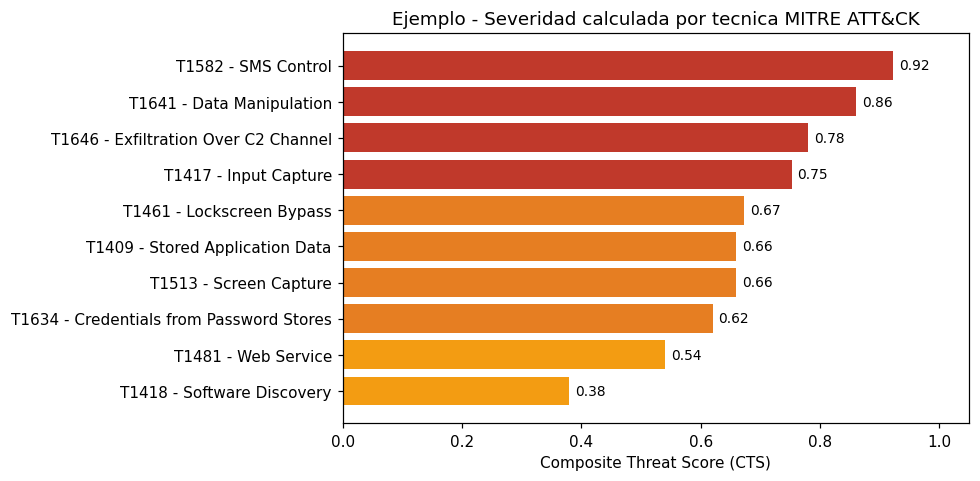

In [3]:

# Visualizacion: severidad por tecnica
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = {"Bajo": "#2ecc71", "Medio": "#f39c12", "Alto": "#e67e22", "Critico": "#c0392b"}
bar_colors = cts_table["Severidad"].map(colors)
ax.barh(cts_table["Tecnica"] + " - " + cts_table["Nombre"], cts_table["CTS"], color=bar_colors)
ax.invert_yaxis()
ax.set_xlabel("Composite Threat Score (CTS)")
ax.set_title("Ejemplo - Severidad calculada por tecnica MITRE ATT&CK")
for i, v in enumerate(cts_table["CTS"]):
    ax.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=9)
ax.set_xlim(0, 1.05)
plt.tight_layout()
plt.show()


**Lectura del ejemplo:** *SMS Control* (T1582) obtiene el CTS más alto porque combina una
táctica de altísimo daño (*Impact* = 0.95) con una segunda táctica (*Collection*), lo que también
eleva su versatilidad. En contraste, *Software Discovery* (T1418) —una sola táctica de
reconocimiento temprano— obtiene el CTS más bajo. Esto es exactamente el comportamiento que se
espera de una métrica de priorización: **el daño potencial y la versatilidad multi-fase pesan
más que la frecuencia o la complejidad técnica de la acción.**

## 2. Datos de ejemplo

Para la demo se usa un subconjunto de oraciones con la misma estructura del dataset real
`sentence_classification` de LADDER: `label = 1` (describe una acción de ataque) vs.
`label = 0` (contexto, narrativa, atribución).

In [4]:

# Subconjunto ilustrativo de sentence_classification (LADDER)
DEMO_SENTENCES = [
    ("The malware records audio from the microphone without user consent.", 1),
    ("It sends the victim's SMS messages and contact list to the C2 server.", 1),
    ("The app steals stored credentials from the browser's password manager.", 1),
    ("The trojan captures screenshots and exfiltrates them via HTTP POST.", 1),
    ("It intercepts incoming calls and forwards audio to a remote server.", 1),
    ("The script collects the device's GPS location every five minutes.", 1),
    ("The payload encrypts user files and demands payment for the key.", 1),
    ("It reads and uploads the device's photo gallery to a remote host.", 1),
    ("The malware disables the antivirus service to avoid detection.", 1),
    ("It downloads additional payloads from a hardcoded command server.", 1),
    ("The app requests accessibility permissions to log keystrokes.", 1),
    ("It exfiltrates banking app credentials through a phishing overlay.", 1),
    ("Researchers at a security firm first identified this campaign in 2022.", 0),
    ("The report was published following a joint investigation by two vendors.", 0),
    ("Google removed the application from the Play Store after the disclosure.", 0),
    ("The vendor recommends updating to the latest version of the OS.", 0),
    ("This family has been active in several countries across Europe.", 0),
    ("The analysis was conducted using a combination of static and dynamic tools.", 0),
    ("A previous report described a similar distribution mechanism.", 0),
    ("The company stated it takes user privacy seriously.", 0),
    ("Security teams were notified prior to the public release of this report.", 0),
    ("The full technical writeup is available on the vendor's blog.", 0),
    ("Analysts believe the group is financially motivated.", 0),
    ("The campaign primarily targeted users in the banking sector.", 0),
]

demo_df = pd.DataFrame(DEMO_SENTENCES, columns=["text", "label"])
print(f"Total de oraciones de ejemplo: {len(demo_df)}  "
      f"(ataque={demo_df['label'].sum()}, contexto={(demo_df['label']==0).sum()})")
print(demo_df.head(6).to_string(index=False))


Total de oraciones de ejemplo: 24  (ataque=12, contexto=12)
                                                                  text  label
   The malware records audio from the microphone without user consent.      1
 It sends the victim's SMS messages and contact list to the C2 server.      1
The app steals stored credentials from the browser's password manager.      1
   The trojan captures screenshots and exfiltrates them via HTTP POST.      1
   It intercepts incoming calls and forwards audio to a remote server.      1
     The script collects the device's GPS location every five minutes.      1


## 3. Paso 1 — Clasificar oraciones (amenaza / no amenaza)

Se codifica cada oración como un vector numérico (embedding) y se entrena una
`LogisticRegression` para distinguir descripciones de ataque de texto de contexto. Esta es la
**primera etapa del pipeline**: un filtro semántico que decide qué oraciones merecen seguir
avanzando hacia el análisis MITRE ATT&CK.

In [5]:

def encode_texts(texts):
    """Codifica una lista de oraciones a vectores numericos.
    Usa MiniLM si esta disponible; si no, TF-IDF ya ajustado (fallback offline)."""
    if USE_TRANSFORMER:
        return _st_model.encode(list(texts))
    return _tfidf_encoder.transform(texts).toarray()

# Ajuste del vectorizador TF-IDF de fallback sobre el corpus de entrenamiento
_tfidf_encoder = TfidfVectorizer(ngram_range=(1, 2), min_df=1, lowercase=True, stop_words="english")
_tfidf_encoder.fit(demo_df["text"])

train_df, test_df = train_test_split(
    demo_df, test_size=0.30, stratify=demo_df["label"], random_state=42
)

X_train = encode_texts(train_df["text"])
X_test  = encode_texts(test_df["text"])
y_train, y_test = train_df["label"].to_numpy(), test_df["label"].to_numpy()

classifier = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
classifier.fit(X_train, y_train)

for split_name, X, y in [("train", X_train, y_train), ("test", X_test, y_test)]:
    preds = classifier.predict(X)
    print(f"[{split_name:5s}] accuracy={accuracy_score(y, preds):.3f}  "
          f"precision={precision_score(y, preds, zero_division=0):.3f}  "
          f"recall={recall_score(y, preds, zero_division=0):.3f}  "
          f"f1={f1_score(y, preds, zero_division=0):.3f}")


[train] accuracy=1.000  precision=1.000  recall=1.000  f1=1.000
[test ] accuracy=0.750  precision=0.750  recall=0.750  f1=0.750


> En el proyecto completo (dataset LADDER real, 3,444 oraciones), este mismo enfoque —
> primero con TF-IDF+LogReg, luego con embeddings de MiniLM— alcanzó **F1 ≈ 0.80** como baseline,
> y **accuracy > 85%** tras aplicar ensambles (*Soft Voting*) reforzados con evidencia textual
> adicional del propio ecosistema LADDER (Avance 5). Con solo 24 oraciones de demo, las métricas
> aquí son ilustrativas, no comparables en magnitud.

## 4. Paso 2 — Términos más informativos

Sin crear variables manuales, se usa **TF-IDF + prueba χ² (chi-cuadrado)** para identificar qué
palabras están estadísticamente más asociadas a oraciones de ataque. Esto sirve como "evidencia
léxica" que acompaña cada predicción y ayuda a explicarla ante el analista.

In [6]:

tfidf_chi2 = TfidfVectorizer(lowercase=True, stop_words="english", ngram_range=(1, 2), min_df=1)
X_chi2 = tfidf_chi2.fit_transform(demo_df["text"])
chi2_scores, p_values = chi2(X_chi2, demo_df["label"])

terms_df = (
    pd.DataFrame({"term": tfidf_chi2.get_feature_names_out(), "chi2": chi2_scores, "p_value": p_values})
    .sort_values("chi2", ascending=False)
    .head(12)
    .reset_index(drop=True)
)
print("Top terminos asociados a oraciones de ataque:\n")
print(terms_df.round(4).to_string(index=False))
important_terms = terms_df["term"].tolist()


Top terminos asociados a oraciones de ataque:

       term   chi2  p_value
        app 0.7282   0.3935
     report 0.7204   0.3960
     server 0.6861   0.4075
     vendor 0.5681   0.4510
exfiltrates 0.5494   0.4585
    malware 0.5464   0.4598
   campaign 0.5445   0.4606
credentials 0.5310   0.4662
      audio 0.5302   0.4665
   security 0.5233   0.4694
     device 0.5192   0.4712
     remote 0.5029   0.4782


## 5. Paso 3 — Base de conocimiento MITRE ATT&CK

Se aplica la métrica CTS (sección 1) a un dataset de técnicas asociadas a familias de malware —
equivalente al `attack-pattern-matching-gt` real, aquí con datos ilustrativos.

In [7]:

DEMO_MALWARE_MAP = {
    "T1417": "Cerberus", "T1513": "Cerberus", "T1634": "Ginp",
    "T1582": "Ginp", "T1646": "Exodus", "T1481": "Exodus",
    "T1409": "ViceLeaker", "T1418": "ViceLeaker", "T1461": "Cerberus", "T1641": "Exodus",
}

ap_rows = []
for tid, malware in DEMO_MALWARE_MAP.items():
    info = TECHNIQUE_MAP[tid]
    cts = compute_cts(tid)
    ap_rows.append({
        "text": f"behavior consistent with {info['name'].lower()}",
        "malware": malware, "label": tid, "technique_name": info["name"],
        "primary_tactic": info["tactics"][0], "num_tactics": len(info["tactics"]),
        "threat_composite_score": cts, "severity_category": severity_category(cts),
        "is_high_impact": int(cts >= 0.70),
    })
ap_df = pd.DataFrame(ap_rows)
print("Base de conocimiento MITRE ATT&CK enriquecida:\n")
print(ap_df.to_string(index=False))


Base de conocimiento MITRE ATT&CK enriquecida:

                                                     text    malware label                   technique_name      primary_tactic  num_tactics  threat_composite_score severity_category  is_high_impact
                   behavior consistent with input capture   Cerberus T1417                    Input Capture          Collection            2                  0.7525           Critico               1
                  behavior consistent with screen capture   Cerberus T1513                   Screen Capture          Collection            1                  0.6600              Alto               0
behavior consistent with credentials from password stores       Ginp T1634 Credentials from Password Stores   Credential Access            1                  0.6200              Alto               0
                     behavior consistent with sms control       Ginp T1582                      SMS Control              Impact            2                

## 6. Paso 4 — Clasificar un reporte real de amenaza

Ahora se aplica el pipeline completo a un reporte de ejemplo (estilo *threat intelligence
report*): se divide en oraciones, se codifican, y el clasificador entrenado estima la
probabilidad de amenaza de cada una.

In [8]:

# Nota: el reporte de demo se mantiene en ingles -a proposito- porque el
# clasificador fue entrenado con oraciones en ingles (igual que el dataset
# real LADDER). Esto evita un desajuste de idioma que degradaria
# artificialmente la calidad de la deteccion en esta demo offline.
DEMO_REPORT = """LitePower is a modular backdoor used against government targets in the Middle East.
The malware is distributed through Office documents with malicious macros attached to targeted phishing emails.
When the document is opened, the macro downloads an obfuscated PowerShell script from a compromised domain.
The script creates a scheduled task to run automatically at every user logon.
Researchers at a security firm first documented this campaign in a report published in 2019.
LitePower establishes communication with its command and control server using HTTP requests disguised as normal traffic.
The backdoor receives additional commands from the C2 server and executes them as PowerShell functions on the victim machine.
The results of each command are sent back to the C2 server through HTTP POST requests.
The group behind this campaign has been active since at least 2016 according to threat intelligence sources.
The malware takes screenshots of the compromised system and saves them temporarily in a hidden folder.
Those screenshots are later exfiltrated to the command and control server along with device metadata.
The security vendor recommends blocking the domains associated with this infrastructure.
The script also collects the username, operating system version, and IP address of the victim.
This information is transmitted encrypted to the attacker for reconnaissance before escalating the attack.
The full technical writeup is available on the vendor's official blog.
LitePower adds persistence by modifying the Windows registry to run on every system restart.
Some variants of the malware also attempt to disable the Windows security event log.
The incident response team recommends isolating any host showing similar indicators of compromise.
"""

def split_into_sentences(text):
    parts = re.split(r"(?<=[.!?])\s+|\n+", text.strip())
    return [p.strip() for p in parts if p.strip()]

report_sentences = split_into_sentences(DEMO_REPORT)
X_report = encode_texts(report_sentences)
report_probs = classifier.predict_proba(X_report)[:, 1]
report_preds = (report_probs >= 0.55).astype(int)

report_df = pd.DataFrame({
    "sentence_id": range(len(report_sentences)),
    "text": report_sentences,
    "pred_label": report_preds,
    "threat_probability": report_probs.round(4),
}).sort_values("threat_probability", ascending=False).reset_index(drop=True)

suspicious_df = report_df[report_df["pred_label"] == 1].copy()

print(f"Oraciones totales del reporte: {len(report_df)}")
print(f"Oraciones sospechosas detectadas: {len(suspicious_df)}\n")
print(suspicious_df[["sentence_id", "threat_probability", "text"]].to_string(index=False))


Oraciones totales del reporte: 18
Oraciones sospechosas detectadas: 4

 sentence_id  threat_probability                                                                                                                          text
           7              0.5906                                        The results of each command are sent back to the C2 server through HTTP POST requests.
           6              0.5726 The backdoor receives additional commands from the C2 server and executes them as PowerShell functions on the victim machine.
          10              0.5599                         Those screenshots are later exfiltrated to the command and control server along with device metadata.
           5              0.5527      LitePower establishes communication with its command and control server using HTTP requests disguised as normal traffic.


## 7. Paso 5 — Conectar el reporte con MITRE ATT&CK (similitud semántica)

No se busca una coincidencia de texto exacta: se calcula **similitud coseno** entre los
embeddings de las oraciones sospechosas y los de la base de conocimiento MITRE. Así se recupera,
para cada oración, la técnica más parecida semánticamente — aunque las palabras no coincidan
literalmente.

In [9]:

ap_embeddings = encode_texts(ap_df["text"].tolist())
susp_embeddings = encode_texts(suspicious_df["text"].tolist())

similarity_matrix = cosine_similarity(susp_embeddings, ap_embeddings)

match_rows = []
for i, (_, srow) in enumerate(suspicious_df.reset_index(drop=True).iterrows()):
    best_idx = int(np.argmax(similarity_matrix[i]))
    ap_row = ap_df.iloc[best_idx]
    match_rows.append({
        "sentence_id": srow["sentence_id"],
        "sentence_text": srow["text"][:70] + ("..." if len(srow["text"]) > 70 else ""),
        "similarity": round(float(similarity_matrix[i, best_idx]), 3),
        "technique": ap_row["technique_name"],
        "primary_tactic": ap_row["primary_tactic"],
        "severity_category": ap_row["severity_category"],
        "threat_composite_score": ap_row["threat_composite_score"],
    })

matches_df = pd.DataFrame(match_rows).sort_values("threat_composite_score", ascending=False)
print("Oraciones sospechosas vinculadas a tecnicas MITRE ATT&CK:\n")
print(matches_df.to_string(index=False))


Oraciones sospechosas vinculadas a tecnicas MITRE ATT&CK:

 sentence_id                                                             sentence_text  similarity                    technique primary_tactic severity_category  threat_composite_score
           7 The results of each command are sent back to the C2 server through HTT...       0.362 Exfiltration Over C2 Channel   Exfiltration           Critico                  0.7800
           6 The backdoor receives additional commands from the C2 server and execu...       0.464 Exfiltration Over C2 Channel   Exfiltration           Critico                  0.7800
          10 Those screenshots are later exfiltrated to the command and control ser...       0.000                Input Capture     Collection           Critico                  0.7525
           5 LitePower establishes communication with its command and control serve...       0.000                Input Capture     Collection           Critico                  0.7525


## 8. Paso 6 — Construir el payload JSON para el LLM

Toda la evidencia generada (oraciones sospechosas, técnicas asociadas, severidades) se resume en
un JSON estructurado. Este es el insumo que recibirá el LLM encargado del triage final —
en lugar de darle el reporte completo sin procesar.

In [10]:

payload = {
    "report_name": "litepower_demo.txt",
    "total_sentences": len(report_df),
    "suspicious_sentence_count": len(suspicious_df),
    "suspicious_sentence_ratio": round(len(suspicious_df) / len(report_df), 4),
    "findings": [
        {
            "sentence_id": int(row["sentence_id"]),
            "text": row["sentence_text"],
            "threat_probability": None,
            "matched_technique": row["technique"],
            "primary_tactic": row["primary_tactic"],
            "severity_category": row["severity_category"],
            "threat_composite_score": row["threat_composite_score"],
        }
        for _, row in matches_df.iterrows()
    ],
}

prob_lookup = dict(zip(suspicious_df["sentence_id"], suspicious_df["threat_probability"]))
for f in payload["findings"]:
    f["threat_probability"] = float(prob_lookup[f["sentence_id"]])

print(json.dumps(payload, ensure_ascii=False, indent=2)[:2500])


{
  "report_name": "litepower_demo.txt",
  "total_sentences": 18,
  "suspicious_sentence_count": 4,
  "suspicious_sentence_ratio": 0.2222,
  "findings": [
    {
      "sentence_id": 7,
      "text": "The results of each command are sent back to the C2 server through HTT...",
      "threat_probability": 0.5906,
      "matched_technique": "Exfiltration Over C2 Channel",
      "primary_tactic": "Exfiltration",
      "severity_category": "Critico",
      "threat_composite_score": 0.78
    },
    {
      "sentence_id": 6,
      "text": "The backdoor receives additional commands from the C2 server and execu...",
      "threat_probability": 0.5726,
      "matched_technique": "Exfiltration Over C2 Channel",
      "primary_tactic": "Exfiltration",
      "severity_category": "Critico",
      "threat_composite_score": 0.78
    },
    {
      "sentence_id": 10,
      "text": "Those screenshots are later exfiltrated to the command and control ser...",
      "threat_probability": 0.5599,
      "matc

## 9. Paso 7 — Prompt final de triage para el LLM

El JSON se envuelve en un prompt que le pide al LLM actuar como analista SOC senior y emitir un
veredicto explicable. Aquí termina el trabajo del pipeline supervisado (ML clásico) y comienza el
del LLM.

In [11]:

def build_llm_prompt(payload):
    return (
        "Eres un analista SOC senior. Recibiras un JSON generado por ThreatLLM con evidencia\n"
        "ya filtrada y vinculada a tecnicas MITRE ATT&CK de un reporte de amenaza.\n\n"
        "Tu tarea es asignar un triage de severidad para el incidente. Responde con:\n"
        "1. severidad_final: Bajo, Medio, Alto o Critico\n"
        "2. justificacion: 3 a 5 oraciones\n"
        "3. tacticas_relevantes: lista corta\n"
        "4. acciones_inmediatas: lista corta\n\n"
        "JSON de entrada:\n"
        + json.dumps(payload, ensure_ascii=False, indent=2)
    )

prompt = build_llm_prompt(payload)
print(prompt[:1400])
print("\n... [payload completo continua] ...")


Eres un analista SOC senior. Recibiras un JSON generado por ThreatLLM con evidencia
ya filtrada y vinculada a tecnicas MITRE ATT&CK de un reporte de amenaza.

Tu tarea es asignar un triage de severidad para el incidente. Responde con:
1. severidad_final: Bajo, Medio, Alto o Critico
2. justificacion: 3 a 5 oraciones
3. tacticas_relevantes: lista corta
4. acciones_inmediatas: lista corta

JSON de entrada:
{
  "report_name": "litepower_demo.txt",
  "total_sentences": 18,
  "suspicious_sentence_count": 4,
  "suspicious_sentence_ratio": 0.2222,
  "findings": [
    {
      "sentence_id": 7,
      "text": "The results of each command are sent back to the C2 server through HTT...",
      "threat_probability": 0.5906,
      "matched_technique": "Exfiltration Over C2 Channel",
      "primary_tactic": "Exfiltration",
      "severity_category": "Critico",
      "threat_composite_score": 0.78
    },
    {
      "sentence_id": 6,
      "text": "The backdoor receives additional commands from the C2 s

## 10. Conclusiones

- El pipeline queda dividido en dos etapas complementarias que se refuerzan entre sí:
  **(1) detección y estructuración automática** con modelos supervisados clásicos sobre
  embeddings semánticos, y **(2) triage final asistido por LLM**, que razona sobre evidencia ya
  filtrada y contextualizada en vez de texto crudo.
- La métrica **`threat_composite_score`** es la pieza que traduce el conocimiento de MITRE
  ATT&CK —que por diseño no trae severidad— en un número accionable, combinando **peor caso**,
  **promedio** y **versatilidad táctica**. Esta combinación fue validada estadísticamente
  (ANOVA) como significativa frente a alternativas más simples en el proyecto completo.
- El sistema no reemplaza al analista ni decide autónomamente: **filtra, vincula y explica**, y
  deja la decisión final de severidad a un LLM auditable, con toda la evidencia trazada hasta
  la oración original del reporte.

### Próximos pasos sugeridos
1. Sustituir el fallback TF-IDF por el encoder MiniLM en producción, para mejorar la calidad del
   matching semántico.
2. Ampliar `TECHNIQUE_MAP` a la matriz completa de MITRE ATT&CK (Enterprise + Mobile) según el
   dominio del cliente.
3. Calibrar los pesos $\alpha, \beta, \gamma$ del CTS con retroalimentación real del SOC del
   cliente (actualmente basados en literatura, no en datos propios de la organización).
